In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [ ]:
df = pd.read_csv("/content/creditcard.csv")

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Feature names grouped
pca_features = [f'V{i}' for i in range(1, 29)]
non_pca_features = ['Time', 'Amount']
target_col = 'Class'
all_features = pca_features + non_pca_features

print(f'PCA features (anonymized):  {pca_features}')
print(f'Non-PCA features:           {non_pca_features}')
print(f'Target:                     {target_col}')

PCA features (anonymized):  ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Non-PCA features:           ['Time', 'Amount']
Target:                     Class


In [ ]:
stats = df.describe().T
stats

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


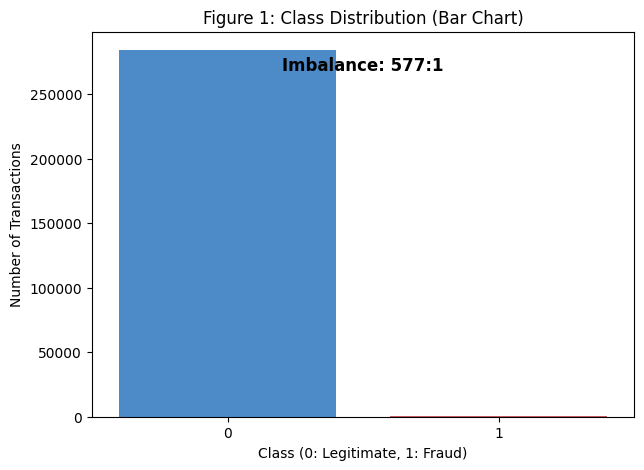

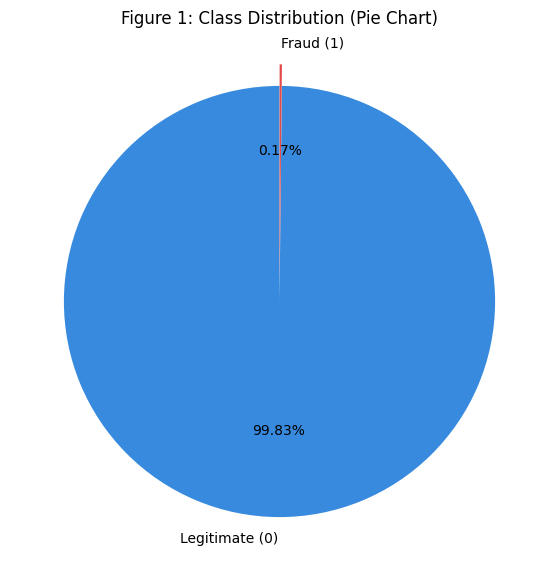

In [ ]:
#Figure 1 — Class Distribution: Bar chart and pie chart showing the 577:1 imbalance ratio. Confirmed that only 0.17% of transactions are fraudulent.
plt.figure(figsize=(7, 5))
sns.countplot(x=target_col, data=df, hue=target_col, palette={0: '#378ADD', 1: '#E24B4A'}, legend=False)
plt.title(f'Figure 1: Class Distribution (Bar Chart)')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Number of Transactions')

# Add the imbalance ratio as text
fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
imbalance_ratio = legit_count // fraud_count
plt.text(0.5, plt.ylim()[1] * 0.9, f'Imbalance: {imbalance_ratio}:1', horizontalalignment='center', fontsize=12, color='black', weight='bold')

plt.show()

plt.figure(figsize=(7, 7))
class_counts = df['Class'].value_counts()
class_labels = ['Legitimate (0)', 'Fraud (1)']
colors = ['#378ADD', '#E24B4A']

plt.pie(class_counts, labels=class_labels, colors=colors, autopct=lambda p: '{:.2f}%'.format(p) if p > 0 else '', startangle=90, explode=[0, 0.1])
plt.title('Figure 1: Class Distribution (Pie Chart)')
plt.show()

Confirmation: There are no missing values in the dataset.


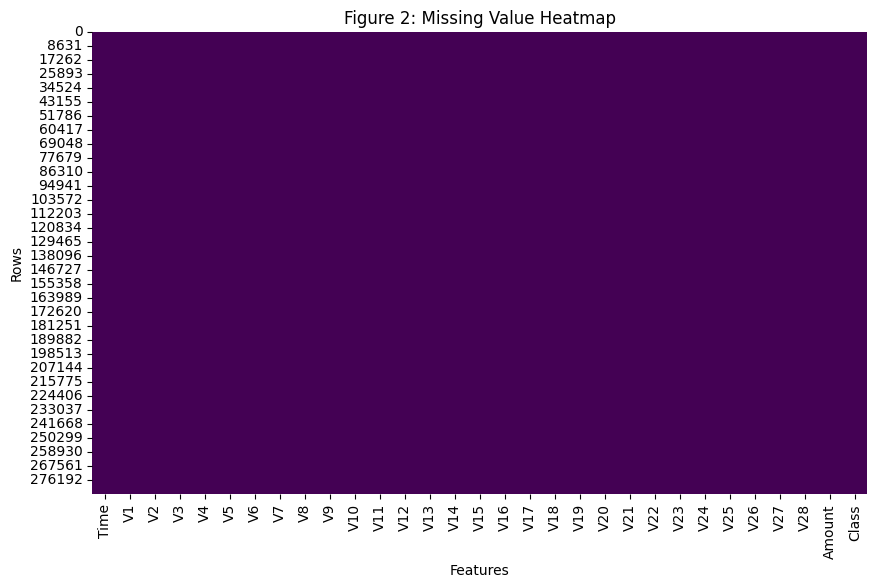

In [ ]:
# Figure 2 — Missing Value Heatmap: Confirmed zero missing values across all features.
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Figure 2: Missing Value Heatmap')
plt.xlabel('Features')
plt.ylabel('Rows')
if df.isnull().sum().sum() == 0:
    print("Confirmation: There are no missing values in the dataset.")
else:
    print("Warning: There are missing values in the dataset. See heatmap for details.")

In [ ]:
stats['skewness'] = df.skew()

In [ ]:
stats['kurtosis'] = df.kurtosis()

In [ ]:
display(stats.round(3))

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Time,284807.0,94813.860,47488.146,0.000,54201.500,84692.000,139320.500,172792.000,-0.036,-1.294
V1,284807.0,0.000,1.959,-56.408,-0.920,0.018,1.316,2.455,-3.281,32.487
V2,284807.0,0.000,1.651,-72.716,-0.599,0.065,0.804,22.058,-4.625,95.773
V3,284807.0,-0.000,1.516,-48.326,-0.890,0.180,1.027,9.383,-2.240,26.620
V4,284807.0,0.000,1.416,-5.683,-0.849,-0.020,0.743,16.875,0.676,2.635
V5,284807.0,0.000,1.380,-113.743,-0.692,-0.054,0.612,34.802,-2.426,206.905
V6,284807.0,0.000,1.332,-26.161,-0.768,-0.274,0.399,73.302,1.827,42.642
V7,284807.0,-0.000,1.237,-43.557,-0.554,0.040,0.570,120.589,2.554,405.607
V8,284807.0,0.000,1.194,-73.217,-0.209,0.022,0.327,20.007,-8.522,220.587
V9,284807.0,-0.000,1.099,-13.434,-0.643,-0.051,0.597,15.595,0.555,3.731


In [ ]:
# Highlight highly skewed features (|skew| > 1)
skewed = stats[stats['skewness'].abs() > 1][['mean', 'std', 'skewness', 'kurtosis']]
print(f'Features with |skewness| > 1 ({len(skewed)} features):')

Features with |skewness| > 1 (19 features):


In [ ]:
display(skewed.sort_values('skewness', key=abs, ascending=False))

,mean,std,skewness,kurtosis
Class,1.727486e-03,0.041527,23.997579,573.887843
Amount,8.834962e+01,250.120109,16.977724,845.092646
V28,-1.227390e-16,0.330083,11.192091,933.397502
V8,1.213481e-16,1.194353,-8.521944,220.586974
V23,2.578648e-16,0.624460,-5.875140,440.088659
V2,3.416908e-16,1.651309,-4.624866,95.773106
V17,-3.772171e-16,0.849337,-3.844914,94.799719
V21,1.654067e-16,0.734524,3.592991,207.287040
V1,1.168375e-15,1.958696,-3.280667,32.486679
V7,-5.556467e-16,1.237094,2.553907,405.607417


Text(0.5, 0.98, 'Figure 3 — Distribution of PCA Features (V1–V28)')

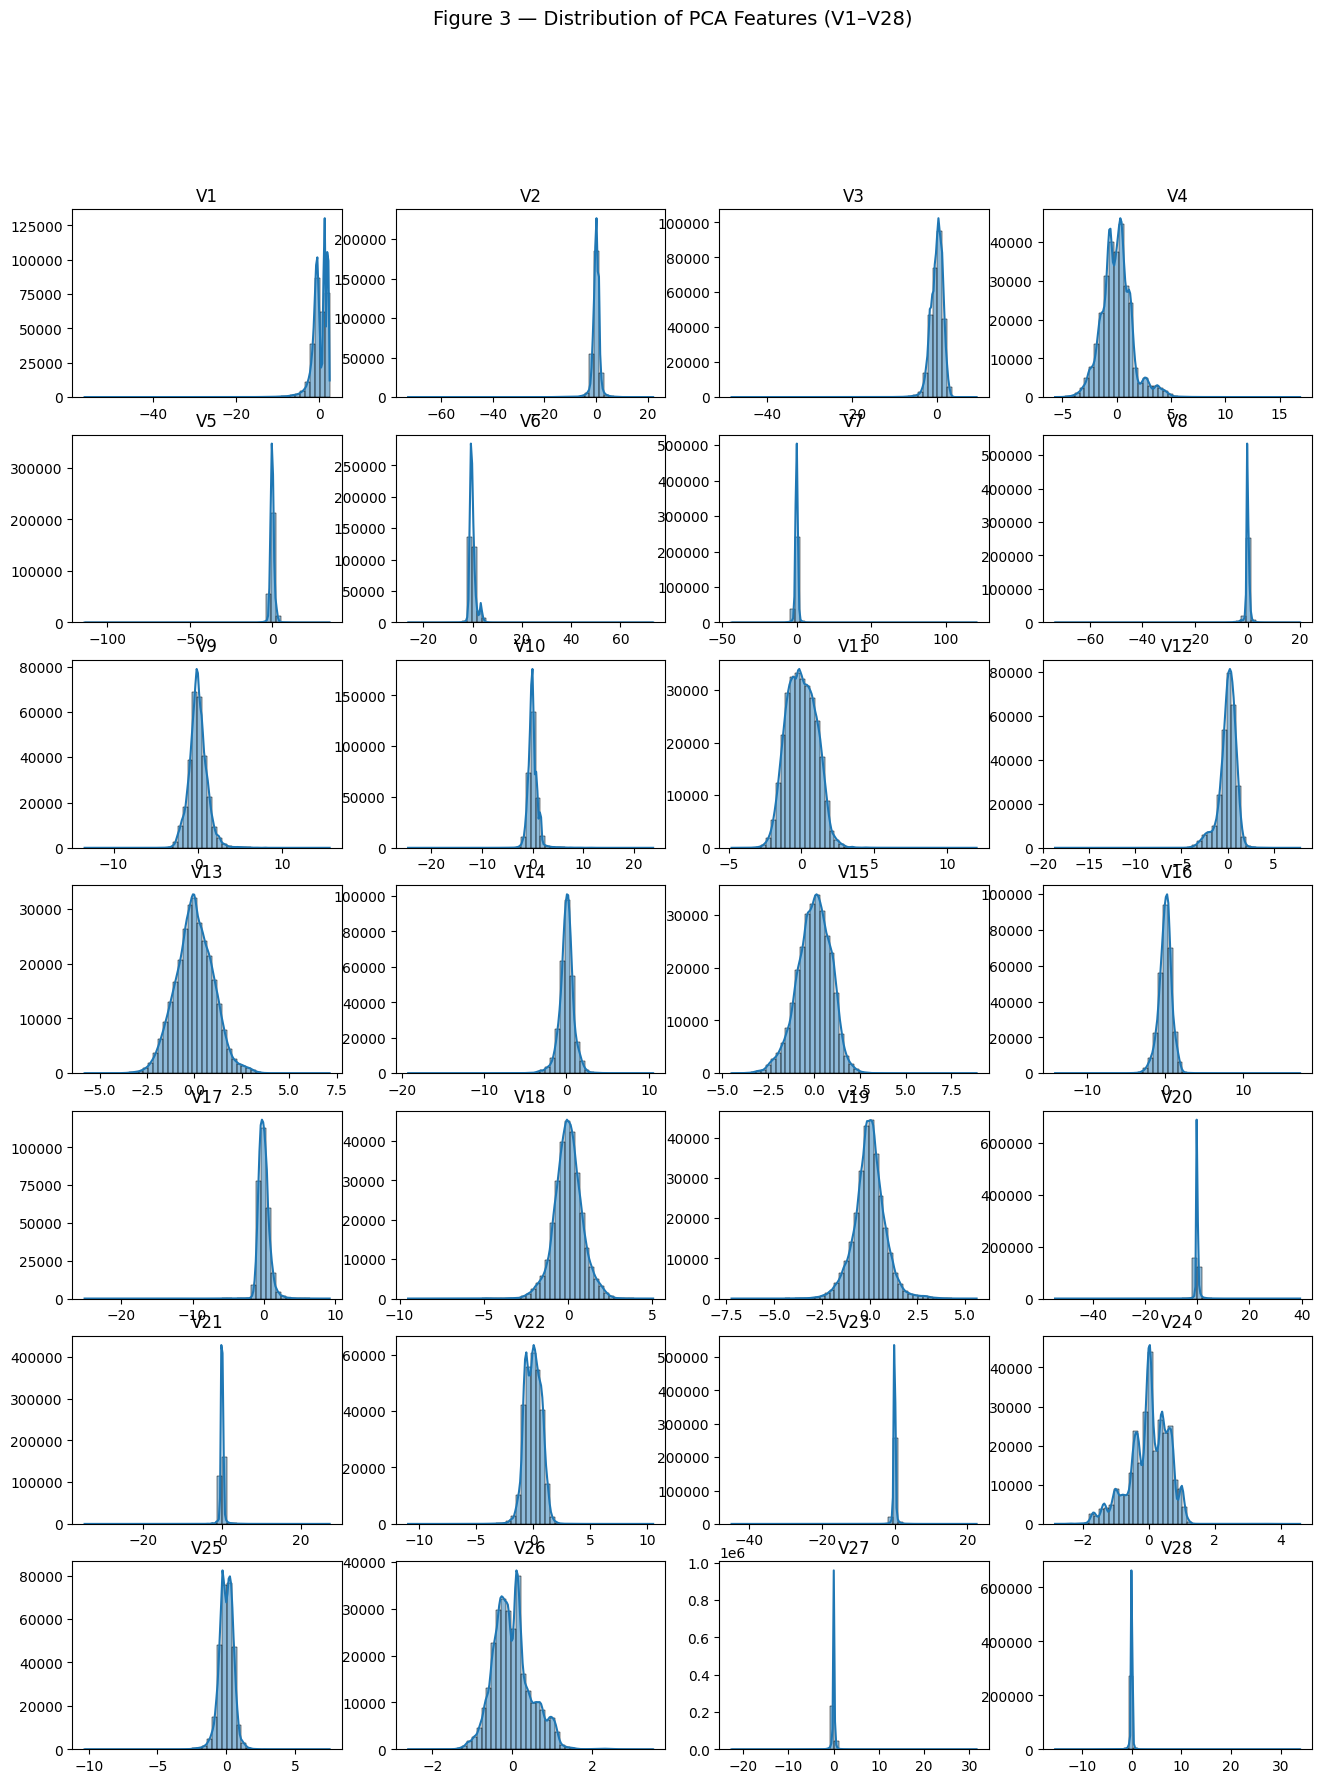

In [ ]:
#Figure 3 — Histograms (V1-V28): All 28 PCA features are approximately normally distributed (as expected from PCA), with varying degrees of kurtosis and skewness.
# PCA features list
pca_features = [f'V{i}' for i in range(1, 29)]

# Create grid (7 rows × 4 columns = 28 plots)
fig, axes = plt.subplots(7, 4, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(pca_features):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Figure 3 — Distribution of PCA Features (V1–V28)', fontsize=14)


In [ ]:
fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
fraud_pct = fraud_count / len(df) * 100

print('Class distribution:')
print(f'  Legitimate (0): {legit_count:>7,}  ({100-fraud_pct:.3f}%)')
print(f'  Fraud      (1): {fraud_count:>7,}  ({fraud_pct:.3f}%)')
print(f'  Imbalance ratio: 1 fraud per {legit_count//fraud_count} legitimate transactions')

Class distribution:
  Legitimate (0): 284,315  (99.827%)
  Fraud      (1):     492  (0.173%)
  Imbalance ratio: 1 fraud per 577 legitimate transactions


Text(0.5, 1.0, 'Figure 4 — Amount and Time Distributions')

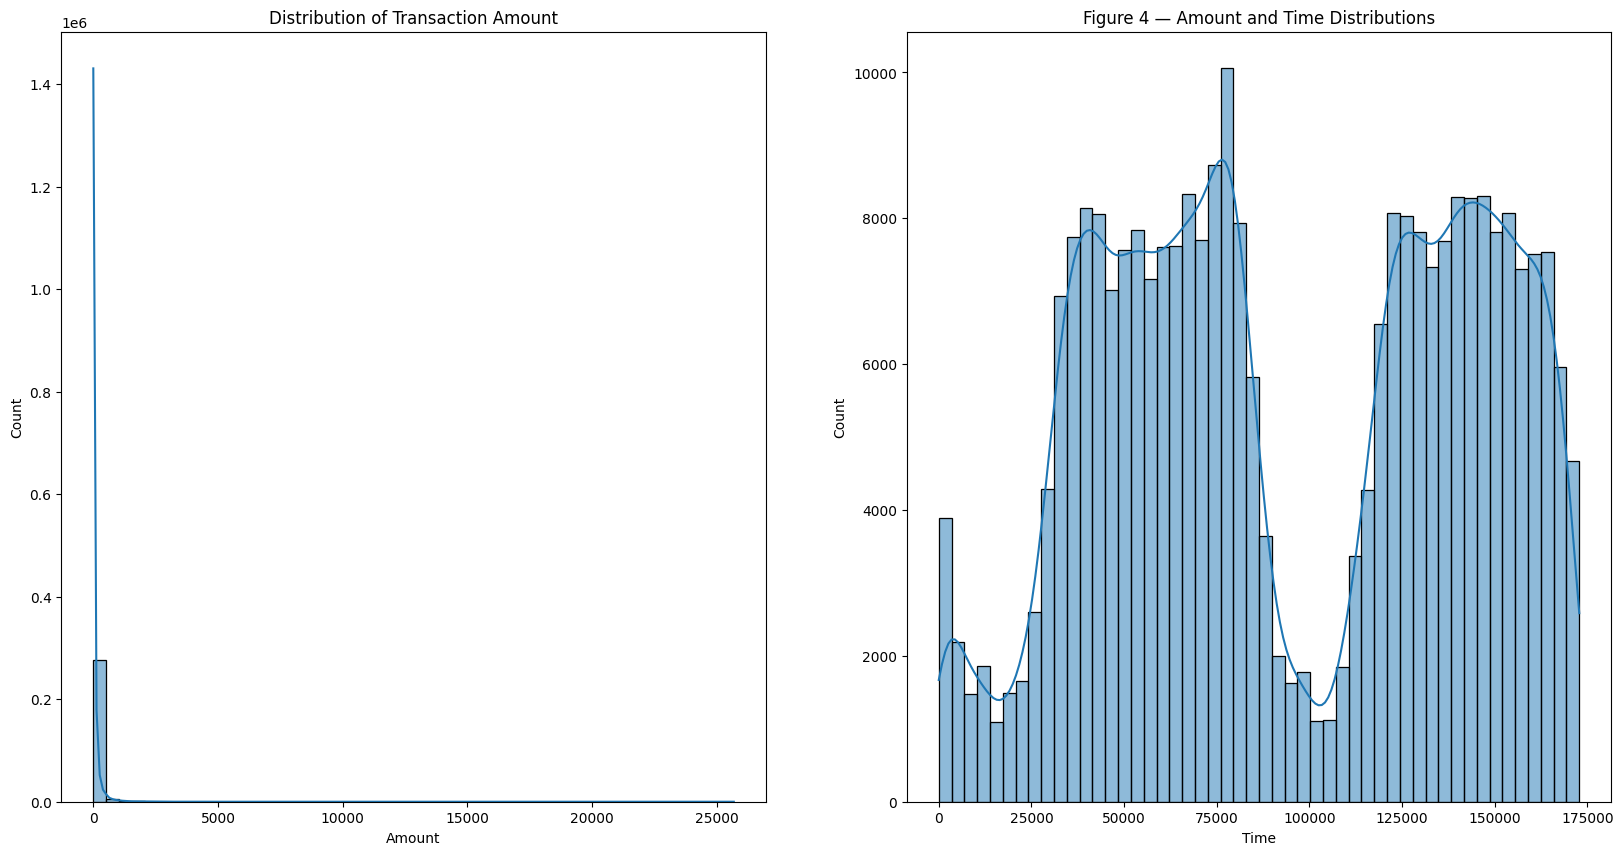

In [ ]:
#Figure 4 — Amount and Time Distributions: Amount is highly right-skewed; Time shows a bimodal pattern consistent with two separate days of transaction activity.
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Transaction Amount')

sns.histplot(df['Time'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Figure 4 — Amount and Time Distributions')


In [ ]:
df['Amount_scaled'] = StandardScaler().fit_transform(df[['Amount']])
df['Time_scaled']   = StandardScaler().fit_transform(df[['Time']])
feature_cols = [f'V{i}' for i in range(1,29)] + ['Amount_scaled','Time_scaled']
X = df[feature_cols]; y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')

Train: 227,845 rows | Test: 56,962 rows


In [ ]:
print('Amount statistics by class:')
display(df.groupby('Class')['Amount'].describe().round(2))

Amount statistics by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.29,250.11,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.21,256.68,0.0,1.00,9.25,105.89,2125.87


In [ ]:
print('Time statistics by class:')
display(df.groupby('Class')['Time'].describe().round(2))

Time statistics by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.20,47484.02,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.81,47835.37,406.0,41241.5,75568.5,128483.0,170348.0


In [ ]:
# Identify the most discriminative V features using mean difference
fraud_means = df[df['Class']==1][pca_features].mean()
legit_means = df[df['Class']==0][pca_features].mean()
mean_diff = (fraud_means - legit_means).abs().sort_values(ascending=False)

print('Top 10 most discriminative PCA features (by |mean difference|):')
display(mean_diff.head(10).rename('abs_mean_difference').to_frame().round(3))


Top 10 most discriminative PCA features (by |mean difference|):


,abs_mean_difference
V3,7.045
V14,6.984
V17,6.677
V12,6.270
V10,5.687
V7,5.578
V1,4.780
V4,4.550
V16,4.147
V11,3.807


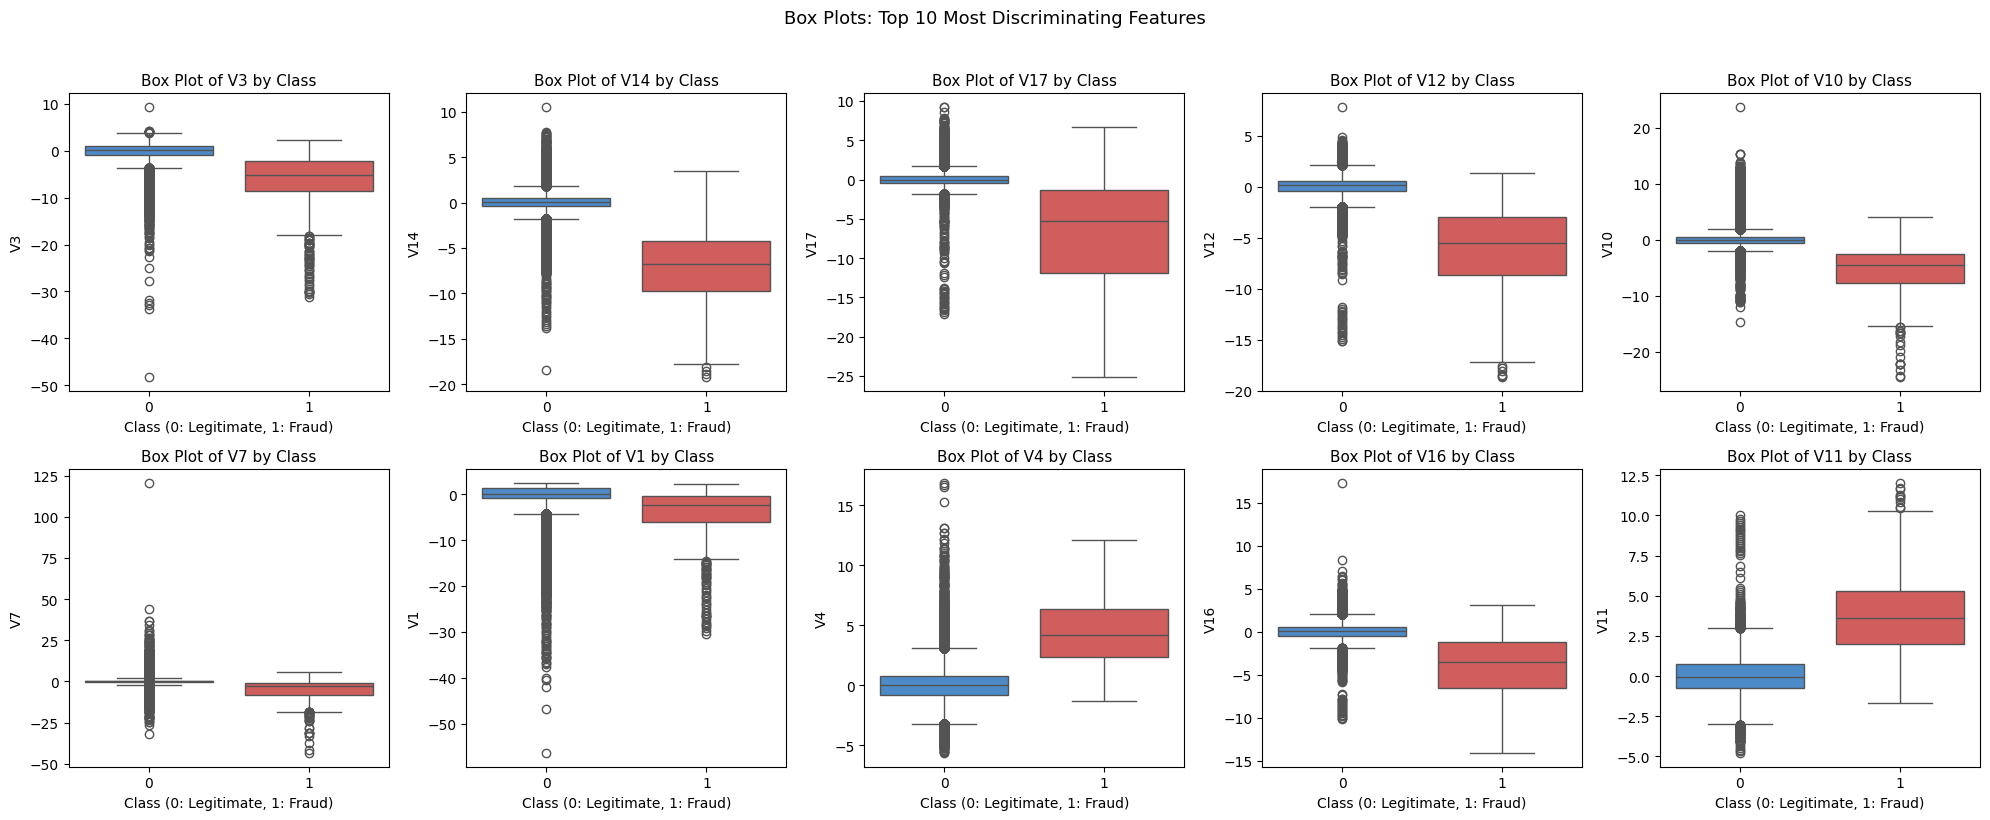

In [ ]:
#Figure 6 — Box Plots (Top 10 Discriminating Features): Features V17, V14, V12, V10, V16, V3, V7 showed the largest differences in median values between legitimate and fraudulent transactions, identifying them as strong candidate predictors.
top_10_features = mean_diff.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feat in enumerate(top_10_features):
    sns.boxplot(x='Class', y=feat, data=df, ax=axes[i], palette={0: '#378ADD', 1: '#E24B4A'}, hue='Class', legend=False)
    axes[i].set_title(f'Box Plot of {feat} by Class', fontsize=11)
    axes[i].set_xlabel('Class (0: Legitimate, 1: Fraud)')
    axes[i].set_ylabel(feat)

plt.suptitle('Box Plots: Top 10 Most Discriminating Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

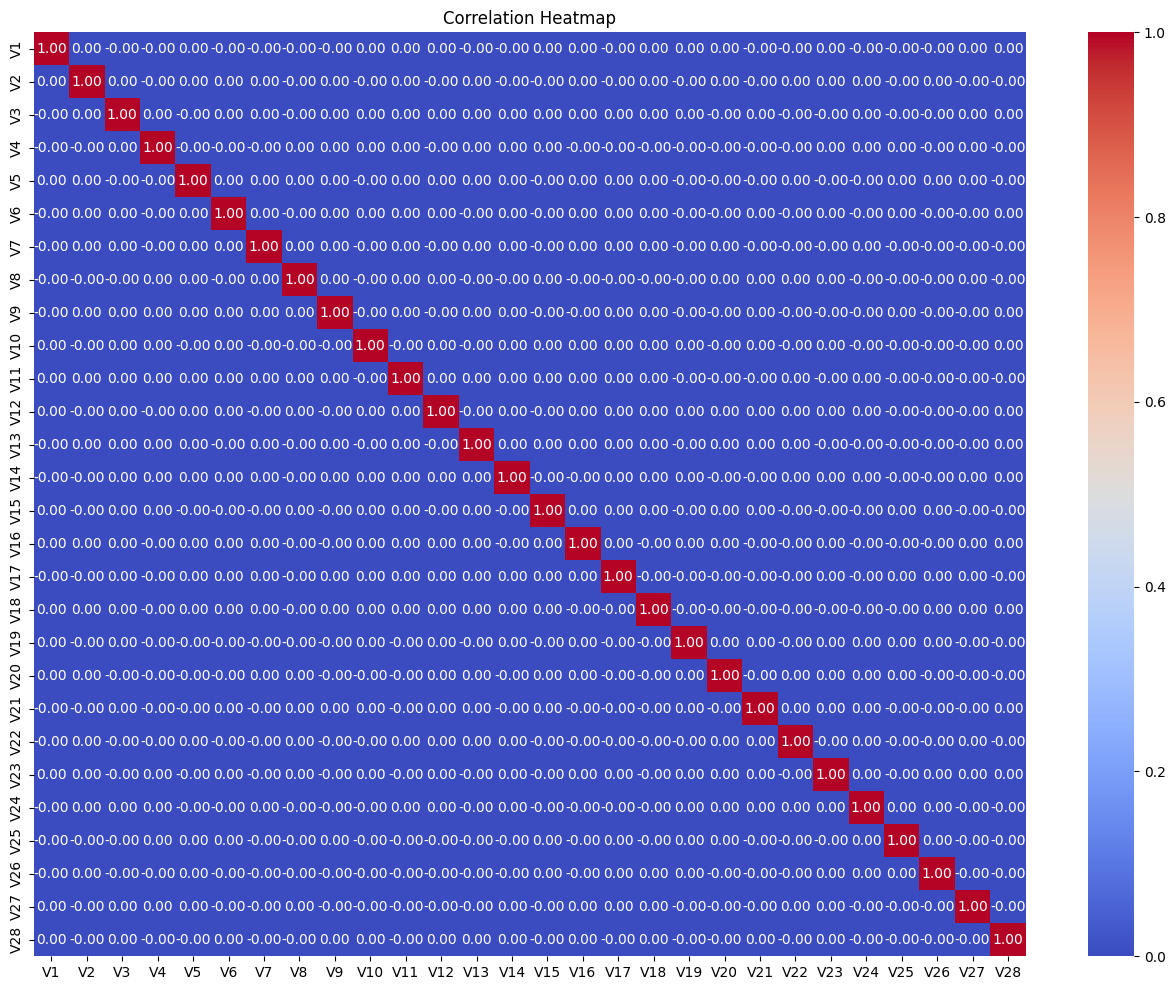

In [ ]:
#Figure 7 — Correlation Heatmap: The full correlation matrix shows low to moderate correlations among V1-V28 features (as expected from PCA orthogonality). No extreme multicollinearity was detected.
plt.figure(figsize=(16, 12))
corr = df[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')

In [ ]:
#Figure 8 — Feature-Target Correlation: V17, V14, V12 show the strongest negative correlations with fraud; V11, V4 show the strongest positive correlations. These features are expected to be the most influential predictors.
# Calculate correlations with the target variable 'Class'
correlation_matrix = df.corr()['Class'].drop('Class')

# Sort by correlation value to find strongest positive and negative
strongest_positive = correlation_matrix.sort_values(ascending=False).head(5)
strongest_negative = correlation_matrix.sort_values(ascending=True).head(5)

print('Top 5 most positively correlated features with Class:')
display(strongest_positive.to_frame().round(4))

print('Top 5 most negatively correlated features with Class:')
display(strongest_negative.to_frame().round(4))

Top 5 most positively correlated features with Class:


,Class
V11,0.1549
V4,0.1334
V2,0.0913
V21,0.0404
V19,0.0348


Top 5 most negatively correlated features with Class:


,Class
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965


In [ ]:
corr = df[pca_features].corr().abs()
high_corr = (corr > 0.5) & (corr < 1)

print("Any high correlations:", high_corr.any().any())

Any high correlations: False


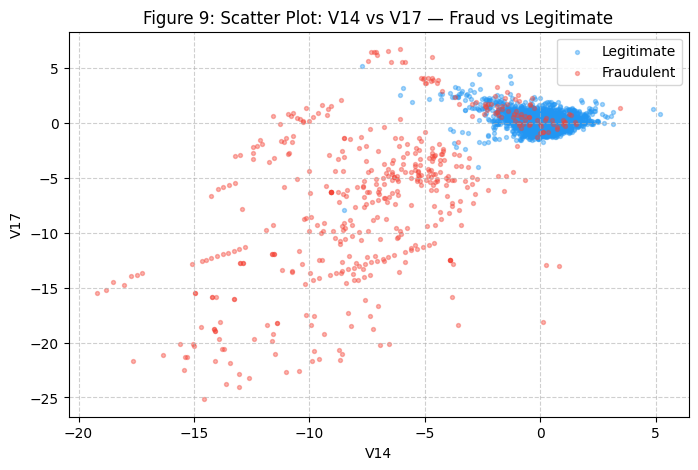

In [ ]:
# Figure 9 — Scatter Plots: Scatter plots of top feature pairs colored by class reveal partial separability between legitimate and fraudulent transactions in the feature space, particularly for V14-V17 combinations.

# Create a sample for visualization due to the large dataset size
sample = pd.concat([df[df['Class']==0].sample(3000, random_state=42), df[df['Class']==1]])

plt.figure(figsize=(8,5))
for cls, label, color in [(0,'Legitimate','#2196F3'),(1,'Fraudulent','#F44336')]:
    s = sample[sample['Class']==cls]
    plt.scatter(s['V14'], s['V17'], c=color, s=8, alpha=0.4, label=label)

plt.xlabel('V14')
plt.ylabel('V17')
plt.title('Figure 9: Scatter Plot: V14 vs V17 — Fraud vs Legitimate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



Text(0, 0.5, 'Number of Fraudulent Transactions')

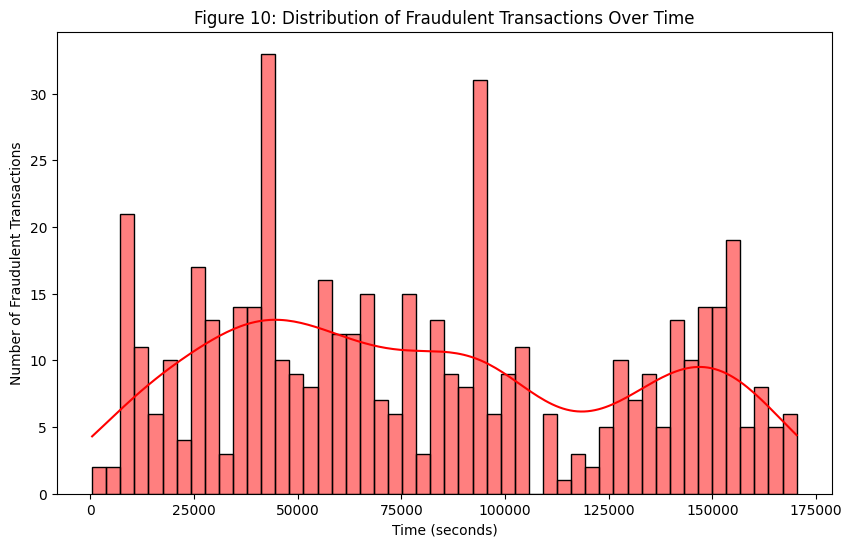

In [ ]:
#Figure 10 — Time Analysis: Fraud transactions are distributed throughout the 48-hour period without strong temporal clustering, suggesting fraudsters operate continuously rather than at specific times.
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, kde=True, color='red')
plt.title('Figure 10: Distribution of Fraudulent Transactions Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Fraudulent Transactions')

Text(0, 0.5, 'Amount')

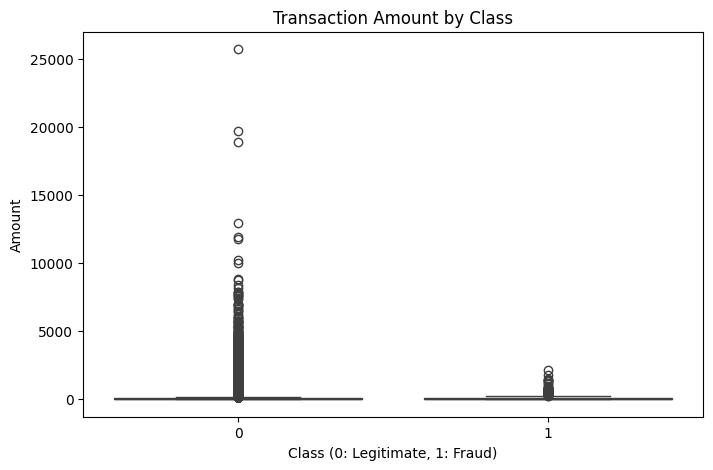

In [ ]:
#Figure 11 —Amount and Log(Amount) by Class: The log-transformed Amount shows a more symmetric distribution and better class separation than the raw Amount, confirming the value of the log transformation.
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Amount')

Text(0, 0.5, 'Amount')

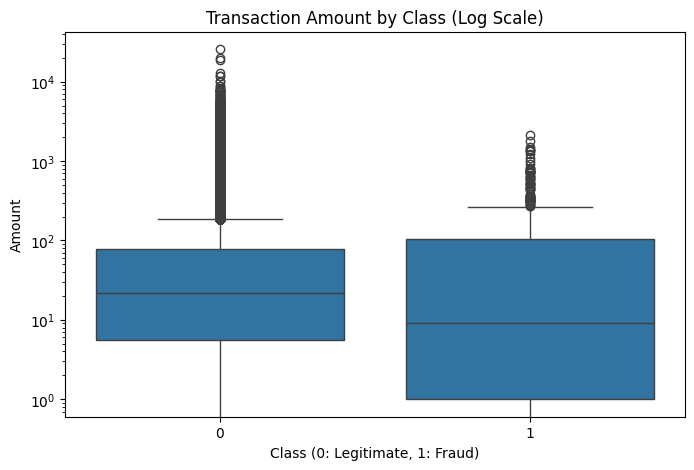

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.yscale('log')
plt.title('Transaction Amount by Class (Log Scale)')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Amount')

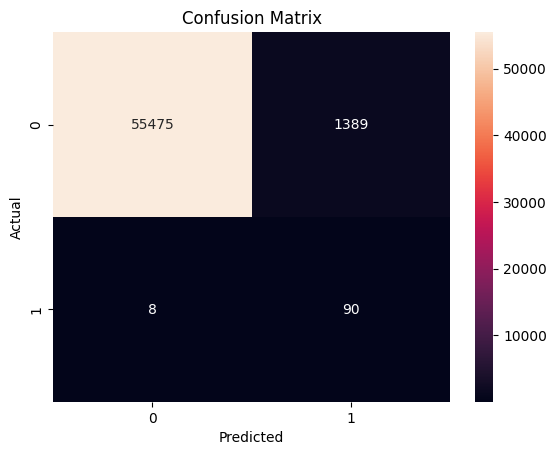

In [ ]:
#Figure 12 — Baseline Confusion Matrix: Logistic Regression with class_weight=balanced achieved AUC-ROC of approximately 0.97, establishing a strong baseline for comparison with Random Forest, XGBoost, and Isolation Forest.
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Train model
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

AUC-ROC: 0.9721669425367221


In [ ]:
def outlier_report(df, columns):
    report_data = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        num_outliers = len(outliers)
        percentage_outliers = (num_outliers / len(df)) * 100
        report_data.append({
            'Feature': col,
            'Number of Outliers': num_outliers,
            'Percentage of Outliers': percentage_outliers,
            'Lower Bound': lower_bound,
            'Upper Bound': upper_bound
        })
    return pd.DataFrame(report_data).set_index('Feature')

print('Outlier report (IQR method):')
report = outlier_report(df, all_features)
display(report)

Outlier report (IQR method):


,Number of Outliers,Percentage of Outliers,Lower Bound,Upper Bound
Feature,,,,
V1,7062,2.479574,-4.274396,4.669664
V2,13526,4.749181,-2.701961,2.907135
V3,3363,1.180800,-3.766705,3.903536
V4,11148,3.914230,-3.236612,3.131313
V5,12295,4.316959,-2.646882,2.567212
V6,22965,8.063355,-2.518586,2.148856
V7,8948,3.141777,-2.240844,2.257204
V8,24134,8.473809,-1.012593,1.131309
V9,8283,2.908285,-2.503452,2.457494


In [ ]:
print('=== DATASET SUMMARY FOR REPORT ===')

print(f'Total transactions:    {len(df):,}')
print(f'Legitimate (Class=0):  {(df["Class"]==0).sum():,}')
print(f'Fraudulent (Class=1):  {(df["Class"]==1).sum():,}')
print(f'Fraud rate:            {df["Class"].mean()*100:.4f}%')

print(f'Features:              {df.shape[1]}')

print(f'Missing values:        {df.isnull().sum().sum()}')

print(f'Time span:             {df["Time"].max()/3600:.1f} hours (~2 days)')

print(f'Amount range:          ${df["Amount"].min():.2f} — ${df["Amount"].max():.2f}')

print(f'Median amount (legit): ${df[df["Class"]==0]["Amount"].median():.2f}')
print(f'Median amount (fraud): ${df[df["Class"]==1]["Amount"].median():.2f}')

=== DATASET SUMMARY FOR REPORT ===
Total transactions:    284,807
Legitimate (Class=0):  284,315
Fraudulent (Class=1):  492
Fraud rate:            0.1727%
Features:              33
Missing values:        0
Time span:             48.0 hours (~2 days)
Amount range:          $0.00 — $25691.16
Median amount (legit): $22.00
Median amount (fraud): $9.25
